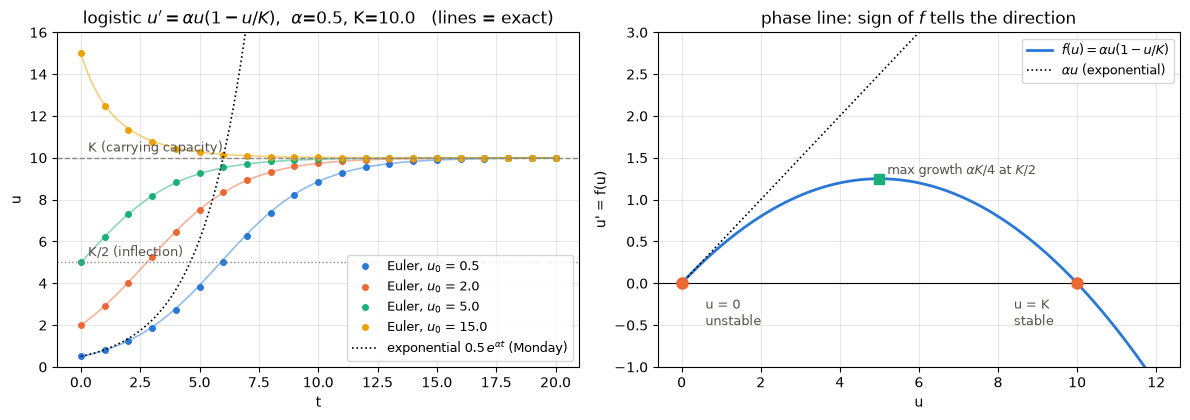

Euler u(T=20.0) = 9.9922   exact = 9.9914   K = 10.0
max Euler error over [0,T] = 0.1036


In [1]:
import numpy as np
import matplotlib.pyplot as plt

alpha, K = 0.5, 10.0                      # growth rate, carrying capacity

def f(t, u):
    return alpha * u * (1 - u / K)        # logistic right-hand side

def u_exact(t, u0):
    return K / (1 + (K / u0 - 1) * np.exp(-alpha * t))

def euler(f, u0, h, T):
    N = int(round(T / h))
    t, y = 0.0, u0
    ts, ys = [t], [y]
    for n in range(N):
        y = y + h * f(t, y); t = t + h
        ts.append(t); ys.append(y)
    return np.array(ts), np.array(ys)

T, h = 20.0, 0.1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

# --- left: solutions from several initial values, Euler vs exact --------------
tt = np.linspace(0, T, 400)
for u0, c in zip([0.5, 2.0, 5.0, 15.0], ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]):
    t, y = euler(f, u0, h, T)
    ax1.plot(tt, u_exact(tt, u0), color=c, lw=1.2, alpha=0.5)
    ax1.plot(t[::10], y[::10], "o", color=c, ms=4, label=f"Euler, $u_0$ = {u0}")
ax1.plot(tt, 0.5 * np.exp(alpha * tt), "k:", lw=1.2, label=r"exponential $0.5\,e^{\alpha t}$ (Monday)")
ax1.axhline(K, color="#8a8984", ls="--", lw=1); ax1.text(0.3, K + 0.3, "K (carrying capacity)", color="#52514e", fontsize=9)
ax1.axhline(K / 2, color="#8a8984", ls=":", lw=1); ax1.text(0.3, K / 2 + 0.3, "K/2 (inflection)", color="#52514e", fontsize=9)
ax1.set_ylim(0, 16); ax1.set_xlabel("t"); ax1.set_ylabel("u")
ax1.set_title(rf"logistic $u' = \alpha u(1-u/K)$,  $\alpha$={alpha}, K={K}   (lines = exact)")
ax1.legend(fontsize=9, loc="lower right"); ax1.grid(alpha=0.3)

# --- right: the right-hand side f(u): where growth is fast, zero, negative ---
uu = np.linspace(0, 12, 300)
ax2.plot(uu, f(0, uu), color="#2a78d6", lw=2, label=r"$f(u) = \alpha u(1-u/K)$")
ax2.plot(uu, alpha * uu, "k:", lw=1.2, label=r"$\alpha u$ (exponential)")
ax2.axhline(0, color="k", lw=0.8)
ax2.plot([0, K], [0, 0], "o", color="#eb6834", ms=8)
ax2.annotate("u = 0\nunstable", (0, 0), (0.6, -0.5), fontsize=9, color="#52514e")
ax2.annotate("u = K\nstable", (K, 0), (K - 1.6, -0.5), fontsize=9, color="#52514e")
ax2.plot(K / 2, alpha * K / 4, "s", color="#1baf7a", ms=7); ax2.text(K / 2 + 0.2, alpha * K / 4 + 0.05, r"max growth $\alpha K/4$ at $K/2$", fontsize=9, color="#52514e")
ax2.set_xlabel("u"); ax2.set_ylabel("u' = f(u)"); ax2.set_title("phase line: sign of $f$ tells the direction")
ax2.set_ylim(-1, 3); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

t, y = euler(f, 0.5, h, T)
print(f"Euler u(T={T}) = {y[-1]:.4f}   exact = {u_exact(T, 0.5):.4f}   K = {K}")
print(f"max Euler error over [0,T] = {np.abs(y - u_exact(t, 0.5)).max():.4f}")


## Logistic fit to Worldometer data 1927–2026 

Logistic fit to Worldometer data 1927–2026 (Euler inside the least-squares loop)
  alpha (growth rate)     = 0.0266 /yr   (2.66 % per year at low population)
  K (carrying capacity)   = 13.14 billion
  u0 (population in 1927) = 1.470 billion   (data: 2.000)
  RMSE                    = 67 million people
  inflection (u = K/2)    = year 2005, fastest growth ≈ 87 million/yr


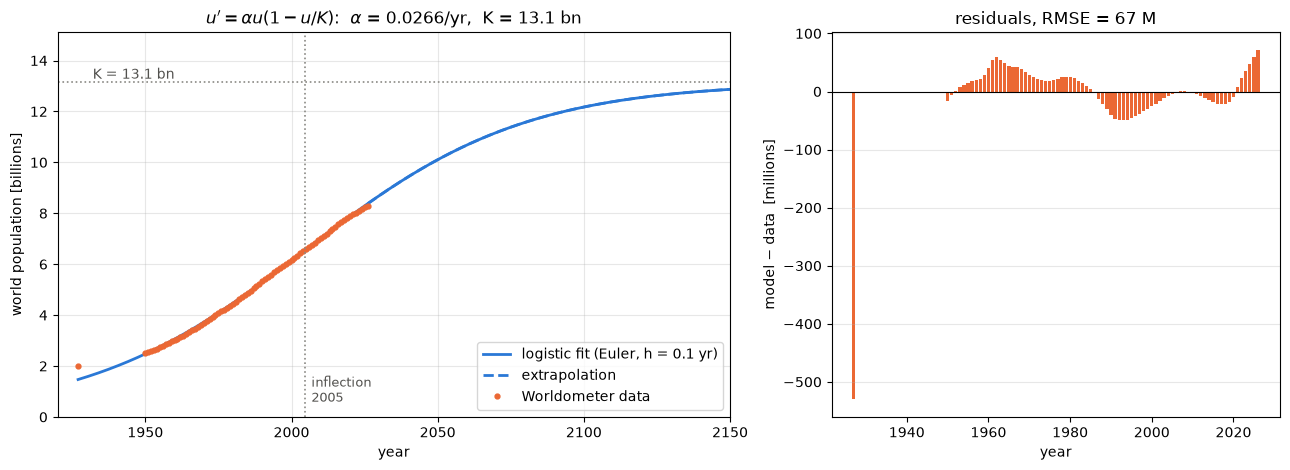


Fit using only data up to a cut-off year:
 data until    alpha   K [bn]  inflection
       1970   0.0184    50.00        2109
       1980   0.0201    50.00        2096
       1990   0.0202    50.00        2095
       2000   0.0209    31.37        2066
       2010   0.0247    15.33        2016
       2026   0.0266    13.14        2005


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================================
# 1) DATA — world population, Worldometer "World Population by Year"
#    https://www.worldometers.info/world-population/world-population-by-year/  (accessed 2026-09-22)
#    1927 milestone + yearly 1950–2026  → 100 years
# ============================================================================
years = np.array([1927] + list(range(1950, 2027)))
pop_billions = np.array([
    2.000,                                                                                   # 1927
    2.493, 2.537, 2.584, 2.634, 2.686, 2.740, 2.795, 2.853, 2.911, 2.966,                    # 1950-59
    3.015, 3.065, 3.123, 3.193, 3.264, 3.335, 3.404, 3.473, 3.545, 3.619,                    # 1960-69
    3.695, 3.770, 3.845, 3.921, 3.996, 4.071, 4.144, 4.218, 4.292, 4.369,                    # 1970-79
    4.448, 4.529, 4.613, 4.697, 4.782, 4.869, 4.958, 5.050, 5.142, 5.234,                    # 1980-89
    5.328, 5.419, 5.506, 5.592, 5.676, 5.759, 5.842, 5.925, 6.007, 6.089,                    # 1990-99
    6.172, 6.255, 6.338, 6.420, 6.503, 6.587, 6.671, 6.757, 6.844, 6.933,                    # 2000-09
    7.022, 7.111, 7.201, 7.292, 7.382, 7.470, 7.559, 7.646, 7.730, 7.811,                    # 2010-19
    7.887, 7.954, 8.021, 8.092, 8.162, 8.232, 8.301,                                         # 2020-26
])
t0 = years[0]

# ============================================================================
# 2) MODEL — logistic ODE solved with EULER
# ============================================================================
def f(u, alpha, K):
    return alpha * u * (1 - u / K)

def euler_logistic(alpha, K, u0, t_end, h=0.1):
    """Euler from t0 to t_end; returns time grid and solution"""
    N = int(round((t_end - t0) / h))
    y = np.empty(N + 1); y[0] = u0
    for n in range(N):
        y[n + 1] = y[n] + h * f(y[n], alpha, K)
    return t0 + h * np.arange(N + 1), y

def model_at(params, t_query, h=0.1):
    """Euler solution evaluated at the data years"""
    alpha, K, u0 = params
    t, y = euler_logistic(alpha, K, u0, t_query.max(), h)
    return np.interp(t_query, t, y)

# ============================================================================
# 3) FIT — least squares:  min  sum_i ( model(t_i) - data_i )^2   over (alpha, K, u0)
# ============================================================================
def residuals(params, t_data, u_data):
    return model_at(params, t_data) - u_data

p0 = [0.03, 12.0, 2.0]                                   # initial guess: 3 %/yr, K = 12 bn, u0 = 2 bn
fit = least_squares(residuals, p0, args=(years, pop_billions),
                    bounds=([0, 5, 1], [0.2, 50, 3]))
alpha, K, u0 = fit.x
rmse = np.sqrt(np.mean(fit.fun**2))
t_inflection = t0 + np.log(K / u0 - 1) / alpha          # where u = K/2, growth fastest

print("Logistic fit to Worldometer data 1927–2026 (Euler inside the least-squares loop)")
print(f"  alpha (growth rate)     = {alpha:.4f} /yr   ({100*alpha:.2f} % per year at low population)")
print(f"  K (carrying capacity)   = {K:.2f} billion")
print(f"  u0 (population in {t0}) = {u0:.3f} billion   (data: {pop_billions[0]:.3f})")
print(f"  RMSE                    = {rmse*1000:.0f} million people")
print(f"  inflection (u = K/2)    = year {t_inflection:.0f}, fastest growth ≈ {alpha*K/4*1000:.0f} million/yr")

# ============================================================================
# 4) PLOT — data, fit, extrapolation, residuals
# ============================================================================
t_ext, y_ext = euler_logistic(alpha, K, u0, 2150)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1.5, 1]))

ax1.plot(t_ext, y_ext, color="#2a78d6", lw=2, label="logistic fit (Euler, h = 0.1 yr)")
ax1.plot(t_ext[t_ext > 2026], y_ext[t_ext > 2026], color="#2a78d6", lw=2, ls="--", label="extrapolation")
ax1.plot(years, pop_billions, "o", color="#eb6834", ms=3.5, label="Worldometer data")
ax1.axhline(K, color="#8a8984", ls=":", lw=1.2); ax1.text(1932, K + 0.15, f"K = {K:.1f} bn", color="#52514e")
ax1.axvline(t_inflection, color="#8a8984", ls=":", lw=1.2)
ax1.text(t_inflection + 2, 0.6, f"inflection\n{t_inflection:.0f}", color="#52514e", fontsize=9)
ax1.set_xlabel("year"); ax1.set_ylabel("world population [billions]")
ax1.set_title(rf"$u' = \alpha u(1 - u/K)$:  $\alpha$ = {alpha:.4f}/yr,  K = {K:.1f} bn")
ax1.set_xlim(1920, 2150); ax1.set_ylim(0, K * 1.15); ax1.legend(loc="lower right"); ax1.grid(alpha=0.3)

ax2.bar(years, fit.fun * 1000, width=0.8, color="#eb6834")
ax2.axhline(0, color="k", lw=0.8)
ax2.set_xlabel("year"); ax2.set_ylabel("model − data  [millions]")
ax2.set_title(f"residuals, RMSE = {rmse*1000:.0f} M"); ax2.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# ============================================================================
# 5) IDENTIFIABILITY — how much data do you need before K is trustworthy?
# ============================================================================
print("\nFit using only data up to a cut-off year:")
print(f"{'data until':>11} {'alpha':>8} {'K [bn]':>8} {'inflection':>11}")
for cut in [1970, 1980, 1990, 2000, 2010, 2026]:
    m = years <= cut
    r = least_squares(residuals, p0, args=(years[m], pop_billions[m]), bounds=([0, 5, 1], [0.2, 50, 3]))
    a_, K_, u0_ = r.x
    print(f"{cut:>11} {a_:8.4f} {K_:8.2f} {t0 + np.log(K_/u0_ - 1)/a_:11.0f}")


sensitivity equations vs finite differences (max relative error): alpha 4.1e-05, K 1.8e-08, u0 3.8e-07
1950: 1 % change in alpha → +0.50 % in u,   in K → +0.09 %,   in u0 → +0.91 %
1980: 1 % change in alpha → +0.93 % in u,   in K → +0.26 %,   in u0 → +0.74 %
2000: 1 % change in alpha → +1.03 % in u,   in K → +0.40 %,   in u0 → +0.60 %
2026: 1 % change in alpha → +0.96 % in u,   in K → +0.59 %,   in u0 → +0.41 %
2060: 1 % change in alpha → +0.66 % in u,   in K → +0.79 %,   in u0 → +0.21 %
2100: 1 % change in alpha → +0.34 % in u,   in K → +0.92 %,   in u0 → +0.08 %

cut-off  cond(J^T J)   corr(s_alpha, s_K)   → can the data separate alpha from K?
   1970     1.30e+04   +0.9715
   1990     2.98e+03   +0.9475
   2010     9.33e+02   +0.8974
   2026     4.22e+02   +0.8008


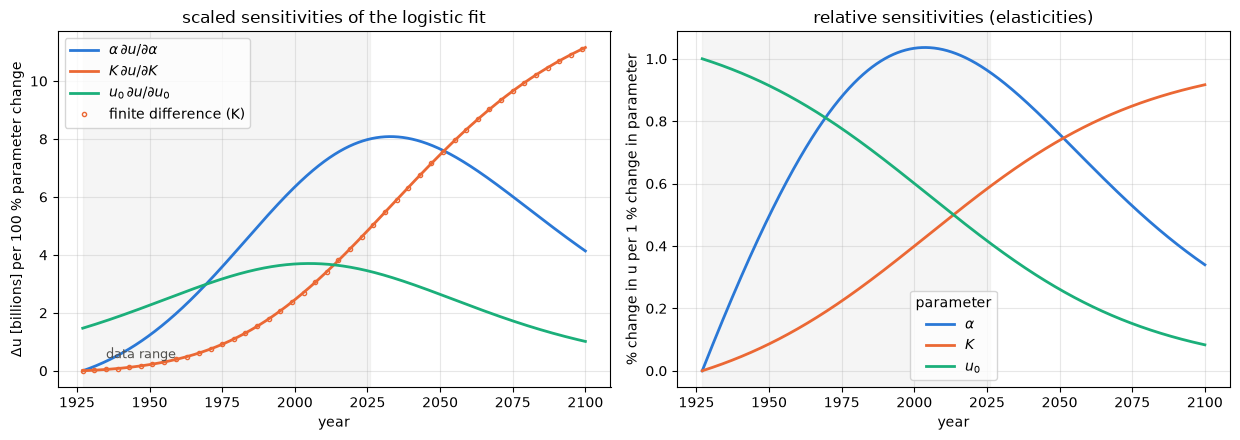

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# fitted logistic parameters for world population (from the previous fit), t0 = 1927
alpha, K, u0 = 0.0266, 13.14, 1.470
t0, T, h = 1927, 2100, 0.1

# ---------------------------------------------------------------- 1) sensitivity equations, solved with Euler alongside u
def f(u):        return alpha * u * (1 - u / K)
def f_u(u):      return alpha * (1 - 2 * u / K)          # df/du
def f_alpha(u):  return u * (1 - u / K)                  # df/dalpha
def f_K(u):      return alpha * u**2 / K**2              # df/dK

N = int(round((T - t0) / h))
t  = t0 + h * np.arange(N + 1)
u  = np.empty(N + 1); s_a = np.empty(N + 1); s_K = np.empty(N + 1); s_u0 = np.empty(N + 1)
u[0], s_a[0], s_K[0], s_u0[0] = u0, 0.0, 0.0, 1.0        # s_u0(0) = du0/du0 = 1

for n in range(N):
    u[n+1]    = u[n]    + h * f(u[n])
    s_a[n+1]  = s_a[n]  + h * (f_u(u[n]) * s_a[n]  + f_alpha(u[n]))
    s_K[n+1]  = s_K[n]  + h * (f_u(u[n]) * s_K[n]  + f_K(u[n]))
    s_u0[n+1] = s_u0[n] + h * (f_u(u[n]) * s_u0[n])

# ---------------------------------------------------------------- 2) check against finite differences
def euler_u(a, k, y0):
    y = np.empty(N + 1); y[0] = y0
    for n in range(N): y[n+1] = y[n] + h * a * y[n] * (1 - y[n] / k)
    return y
eps = 1e-6
fd_a  = (euler_u(alpha + eps, K, u0) - u) / eps
fd_K  = (euler_u(alpha, K + eps, u0) - u) / eps
fd_u0 = (euler_u(alpha, K, u0 + eps) - u) / eps
rel = lambda s, fd: np.abs(s - fd).max() / np.abs(s).max()
print("sensitivity equations vs finite differences (max relative error):",
      f"alpha {rel(s_a, fd_a):.1e}, K {rel(s_K, fd_K):.1e}, u0 {rel(s_u0, fd_u0):.1e}")

# ---------------------------------------------------------------- 3) relative (normalised) sensitivities: % change of u per 1 % change of parameter
rel_a, rel_K, rel_u0 = s_a * alpha / u, s_K * K / u, s_u0 * u0 / u
for yr in [1950, 1980, 2000, 2026, 2060, 2100]:
    i = np.argmin(abs(t - yr))
    print(f"{yr}: 1 % change in alpha → {rel_a[i]:+.2f} % in u,   in K → {rel_K[i]:+.2f} %,   in u0 → {rel_u0[i]:+.2f} %")

# ---------------------------------------------------------------- 4) identifiability from J^T J at different data cut-offs
years = np.array([1927] + list(range(1950, 2027)))
print("\ncut-off  cond(J^T J)   corr(s_alpha, s_K)   → can the data separate alpha from K?")
for cut in [1970, 1990, 2010, 2026]:
    yrs = years[years <= cut]
    idx = np.array([np.argmin(abs(t - y)) for y in yrs])
    J = np.column_stack([rel_a[idx], rel_K[idx], rel_u0[idx]])
    corr = np.corrcoef(J[:, 0], J[:, 1])[0, 1]
    print(f"{cut:>7}  {np.linalg.cond(J.T @ J):11.2e}   {corr:+.4f}")

# ---------------------------------------------------------------- plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))
ax1.plot(t, s_a * alpha, color="#2a78d6", lw=2, label=r"$\alpha\,\partial u/\partial\alpha$")
ax1.plot(t, s_K * K,     color="#eb6834", lw=2, label=r"$K\,\partial u/\partial K$")
ax1.plot(t, s_u0 * u0,   color="#1baf7a", lw=2, label=r"$u_0\,\partial u/\partial u_0$")
ax1.plot(t[::40], fd_K[::40] * K, "o", color="#eb6834", ms=3, mfc="none", label="finite difference (K)")
ax1.axvspan(1927, 2026, color="#8a8984", alpha=0.08); ax1.text(1935, ax1.get_ylim()[1]*0.02 + 0.2, "data range", color="#52514e", fontsize=9)
ax1.set_xlabel("year"); ax1.set_ylabel("Δu [billions] per 100 % parameter change")
ax1.set_title("scaled sensitivities of the logistic fit"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(t, rel_a, color="#2a78d6", lw=2, label=r"$\alpha$")
ax2.plot(t, rel_K, color="#eb6834", lw=2, label=r"$K$")
ax2.plot(t, rel_u0, color="#1baf7a", lw=2, label=r"$u_0$")
ax2.axvspan(1927, 2026, color="#8a8984", alpha=0.08)
ax2.set_xlabel("year"); ax2.set_ylabel("% change in u per 1 % change in parameter")
ax2.set_title("relative sensitivities (elasticities)"); ax2.legend(title="parameter"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Levenberg–Marquardt, start (alpha, K, u0) = [ 0.1 30.   2. ]
 it     S=½|r|²         λ    alpha        K      u0  step
  0  1.7858e+04   1.0e-02   0.1000    30.00   2.000  start
  1  1.3342e+02   1.0e-03   0.0674     7.38   1.870  accept
  2  1.3342e+02   1.0e-02   0.0674     7.38   1.870  reject
  3  1.3342e+02   1.0e-01   0.0674     7.38   1.870  reject
  4  1.3342e+02   1.0e+00   0.0674     7.38   1.870  reject
  5  1.6100e+01   1.0e-01   0.0460     7.03   1.070  accept
  6  4.9289e+00   1.0e-02   0.0418     8.27   0.967  accept
  7  4.0740e+00   1.0e-03   0.0326     9.83   1.207  accept
  8  2.1229e+00   1.0e-04   0.0270    11.99   1.437  accept
  9  1.8116e-01   1.0e-05   0.0266    13.13   1.472  accept
 10  1.7466e-01   1.0e-06   0.0266    13.14   1.470  accept
 11  1.7466e-01   1.0e-07   0.0266    13.14   1.470  accept
 12  1.7466e-01   1.0e-08   0.0266    13.14   1.470  accept
 13  1.7466e-01   1.0e-09   0.0266    13.14   1.470  accept

ours : alpha=0.02663 K=13.136 u0=1.4697  

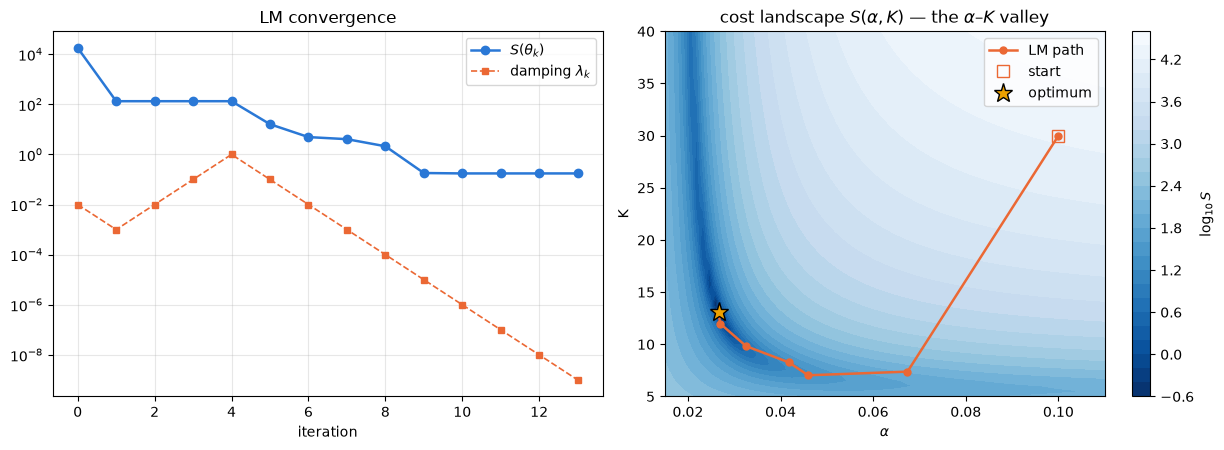

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ---------------------------------------------------------------- data (Worldometer, 1927 + 1950–2026)
years = np.array([1927] + list(range(1950, 2027)))
data = np.array([
    2.000,
    2.493, 2.537, 2.584, 2.634, 2.686, 2.740, 2.795, 2.853, 2.911, 2.966,
    3.015, 3.065, 3.123, 3.193, 3.264, 3.335, 3.404, 3.473, 3.545, 3.619,
    3.695, 3.770, 3.845, 3.921, 3.996, 4.071, 4.144, 4.218, 4.292, 4.369,
    4.448, 4.529, 4.613, 4.697, 4.782, 4.869, 4.958, 5.050, 5.142, 5.234,
    5.328, 5.419, 5.506, 5.592, 5.676, 5.759, 5.842, 5.925, 6.007, 6.089,
    6.172, 6.255, 6.338, 6.420, 6.503, 6.587, 6.671, 6.757, 6.844, 6.933,
    7.022, 7.111, 7.201, 7.292, 7.382, 7.470, 7.559, 7.646, 7.730, 7.811,
    7.887, 7.954, 8.021, 8.092, 8.162, 8.232, 8.301])
t0, h = 1927, 0.1

# ---------------------------------------------------------------- model + sensitivities in ONE Euler loop  ->  residual r and Jacobian J
def residual_and_jacobian(theta):
    alpha, K, u0 = theta
    N = int(round((years[-1] - t0) / h))
    t = t0 + h * np.arange(N + 1)
    u = np.empty(N + 1); S = np.zeros((N + 1, 3)); u[0] = u0; S[0, 2] = 1.0
    for n in range(N):
        un = u[n]
        fu = alpha * (1 - 2 * un / K)
        u[n+1]    = un + h * alpha * un * (1 - un / K)
        S[n+1, 0] = S[n, 0] + h * (fu * S[n, 0] + un * (1 - un / K))     # d/dalpha
        S[n+1, 1] = S[n, 1] + h * (fu * S[n, 1] + alpha * un**2 / K**2)  # d/dK
        S[n+1, 2] = S[n, 2] + h * (fu * S[n, 2])                         # d/du0
    idx = np.rint((years - t0) / h).astype(int)
    return u[idx] - data, S[idx]

# ---------------------------------------------------------------- Levenberg–Marquardt from scratch
def levenberg_marquardt(theta, lam=1e-2, nu=10.0, max_iter=50, tol=1e-10, verbose=True):
    r, J = residual_and_jacobian(theta)
    S = 0.5 * r @ r
    history = [(0, S, lam, *theta, "start")]
    for k in range(1, max_iter + 1):
        A = J.T @ J
        g = J.T @ r
        D = np.diag(np.diag(A))
        delta = np.linalg.solve(A + lam * D, -g)          # LM step
        r_new, J_new = residual_and_jacobian(theta + delta)
        S_new = 0.5 * r_new @ r_new
        S_prev = S
        if S_new < S:                                     # accept: move, trust Gauss-Newton more
            theta, r, J, S = theta + delta, r_new, J_new, S_new
            lam /= nu; status = "accept"
        else:                                             # reject: stay, damp harder
            lam *= nu; status = "reject"
        history.append((k, S, lam, *theta, status))
        if status == "accept" and (S_prev - S) < tol * S:      # converged: S no longer decreases
            break
    if verbose:
        print(f"{'it':>3} {'S=½|r|²':>11} {'λ':>9} {'alpha':>8} {'K':>8} {'u0':>7}  step")
        for row in history:
            print(f"{row[0]:3d} {row[1]:11.4e} {row[2]:9.1e} {row[3]:8.4f} {row[4]:8.2f} {row[5]:7.3f}  {row[6]}")
    return theta, np.array([[hh[0], hh[1], hh[2]] for hh in history])

theta0 = np.array([0.10, 30.0, 2.0])                      # deliberately poor start: 10 %/yr growth, K = 30 bn
print("Levenberg–Marquardt, start (alpha, K, u0) =", theta0)
theta_lm, hist = levenberg_marquardt(theta0)

# ---------------------------------------------------------------- compare: scipy LM, and plain Gauss–Newton from the same start
sp = least_squares(lambda th: residual_and_jacobian(th)[0], theta0, jac=lambda th: residual_and_jacobian(th)[1], method="lm")
print(f"\nours : alpha={theta_lm[0]:.5f} K={theta_lm[1]:.3f} u0={theta_lm[2]:.4f}  S={0.5*residual_and_jacobian(theta_lm)[0]@residual_and_jacobian(theta_lm)[0]:.4e}")
print(f"scipy: alpha={sp.x[0]:.5f} K={sp.x[1]:.3f} u0={sp.x[2]:.4f}  S={0.5*sp.fun@sp.fun:.4e}   (nfev={sp.nfev})")

print("\nplain Gauss–Newton (λ = 0) from the same start:")
th = theta0.copy()
for k in range(8):
    r, J = residual_and_jacobian(th)
    try:
        th = th + np.linalg.solve(J.T @ J, -J.T @ r)
        print(f"  it {k+1}: alpha={th[0]:8.4f} K={th[1]:9.2f} u0={th[2]:8.3f}")
        if not np.all(np.isfinite(th)) or th[0] <= 0 or th[1] <= 0 or th[2] <= 0: print("  → negative parameter: Gauss–Newton diverged"); break
    except Exception as e:
        print("  failed:", e); break

# ---------------------------------------------------------------- plot: convergence + the S(alpha, K) landscape with the LM path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax1.semilogy(hist[:, 0], hist[:, 1], "o-", color="#2a78d6", lw=1.8, label=r"$S(\theta_k)$")
ax1.semilogy(hist[:, 0], hist[:, 2], "s--", color="#eb6834", lw=1.2, ms=4, label=r"damping $\lambda_k$")
ax1.set_xlabel("iteration"); ax1.set_title("LM convergence"); ax1.legend(); ax1.grid(alpha=0.3, which="both")

# landscape in (alpha, K) with u0 fixed at its optimum
A, Kg = np.meshgrid(np.linspace(0.015, 0.11, 70), np.linspace(5, 40, 70))
Z = np.empty_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        r, _ = residual_and_jacobian([A[i, j], Kg[i, j], theta_lm[2]]); Z[i, j] = 0.5 * r @ r
cs = ax2.contourf(A, Kg, np.log10(Z), levels=25, cmap="Blues_r")
plt.colorbar(cs, ax=ax2, label=r"$\log_{10} S$")
# re-run LM to record the (alpha, K) path for the picture
th, lam, pts = theta0.copy(), 1e-2, [theta0[:2].copy()]
r, J = residual_and_jacobian(th); Sc = 0.5 * r @ r
for k in range(30):
    A_ = J.T @ J; d = np.linalg.solve(A_ + lam * np.diag(np.diag(A_)), -J.T @ r)
    rn, Jn = residual_and_jacobian(th + d); Sn = 0.5 * rn @ rn
    if Sn < Sc: th, r, J, Sc, lam = th + d, rn, Jn, Sn, lam / 10; pts.append(th[:2].copy())
    else: lam *= 10
pts = np.array(pts)
ax2.plot(pts[:, 0], pts[:, 1], "o-", color="#eb6834", lw=1.8, ms=5, label="LM path")
ax2.plot(*theta0[:2], "s", color="#eb6834", ms=9, mfc="none", label="start")
ax2.plot(*theta_lm[:2], "*", color="#eda100", ms=14, mec="k", label="optimum")
ax2.set_xlabel(r"$\alpha$"); ax2.set_ylabel("K"); ax2.set_title(r"cost landscape $S(\alpha, K)$ — the $\alpha$–$K$ valley")
ax2.legend(loc="upper right")
plt.tight_layout(); plt.show()
